In [1]:
import pandas as pd 
import matplotlib.pyplot as plt 
import numpy as np 
import seaborn as sns 
import sqlite3


In [2]:
df = pd.read_csv("../data/medical_insurance_2026_kaggle.csv")
df1 = pd.read_csv("../data/health_insurance_cost_and_risk_dataset.csv")

In [3]:
df.head()

,record_date,year,quarter,age,age_group,sex,sex_female,bmi,bmi_category,children,...,region,region_northeast,region_northwest,region_southeast,region_southwest,charges,monthly_premium_est,charges_per_child,insurance_tier,bmi_age_interaction
0,2024-02-01,2024,1,19,Young Adult (18-25),female,1,27.90,Overweight,0,...,southwest,0,0,0,1,16884.92,1407.08,0.00,Platinum,530.10
1,2024-12-30,2024,4,18,Young Adult (18-25),male,0,33.77,Obese Class I,1,...,southeast,0,0,1,0,1725.55,143.80,1725.55,Bronze,607.86
2,2023-05-11,2023,2,28,Adult (26-35),male,0,33.00,Obese Class I,3,...,southeast,0,0,1,0,4449.46,370.79,1483.15,Silver,924.00
3,2024-07-18,2024,3,33,Adult (26-35),male,0,22.70,Normal Weight,0,...,northwest,0,1,0,0,21984.47,1832.04,0.00,Diamond,749.10
4,2024-02-05,2024,1,32,Adult (26-35),male,0,28.88,Overweight,0,...,northwest,0,1,0,0,3866.86,322.24,0.00,Bronze,924.16


checked for missing value and none were found. If missing value were identified they would be evaluated and depending on the variable and amount of missing data, values may be retained or dropped.  

In [4]:
df.isnull().sum()

record_date            0
year                   0
quarter                0
age                    0
age_group              0
sex                    0
sex_female             0
bmi                    0
bmi_category           0
children               0
smoker                 0
smoker_flag            0
is_high_risk           0
risk_score             0
region                 0
region_northeast       0
region_northwest       0
region_southeast       0
region_southwest       0
charges                0
monthly_premium_est    0
charges_per_child      0
insurance_tier         0
bmi_age_interaction    0
dtype: int64

checked for data types and the record_date was found to have string instead of integer.  

In [5]:
df.dtypes

record_date                str
year                     int64
quarter                  int64
age                      int64
age_group                  str
sex                        str
sex_female               int64
bmi                    float64
bmi_category               str
children                 int64
smoker                     str
smoker_flag              int64
is_high_risk             int64
risk_score             float64
region                     str
region_northeast         int64
region_northwest         int64
region_southeast         int64
region_southwest         int64
charges                float64
monthly_premium_est    float64
charges_per_child      float64
insurance_tier             str
bmi_age_interaction    float64
dtype: object

record_date data type was changed from string to datetime format.

In [6]:
df["record_date"]=pd.to_datetime(df["record_date"])
df.dtypes

record_date            datetime64[us]
year                            int64
quarter                         int64
age                             int64
age_group                         str
sex                               str
sex_female                      int64
bmi                           float64
bmi_category                      str
children                        int64
smoker                            str
smoker_flag                     int64
is_high_risk                    int64
risk_score                    float64
region                            str
region_northeast                int64
region_northwest                int64
region_southeast                int64
region_southwest                int64
charges                       float64
monthly_premium_est           float64
charges_per_child             float64
insurance_tier                    str
bmi_age_interaction           float64
dtype: object

Verified that there are no duplicate rows in the dataset. If any duplicate rows had been identified, they would have been be dropped.

In [7]:
df.duplicated().sum()


np.int64(0)

In [8]:
df.drop(columns=["record_date", "year", "quarter", "sex_female", "smoker_flag", "region_northeast", "region_northwest", "region_southeast", "region_southwest"], inplace=True)
df.head()

,age,age_group,sex,bmi,bmi_category,children,smoker,is_high_risk,risk_score,region,charges,monthly_premium_est,charges_per_child,insurance_tier,bmi_age_interaction
0,19,Young Adult (18-25),female,27.90,Overweight,0,yes,1,5.35,southwest,16884.92,1407.08,0.00,Platinum,530.10
1,18,Young Adult (18-25),male,33.77,Obese Class I,1,no,1,1.40,southeast,1725.55,143.80,1725.55,Bronze,607.86
2,28,Adult (26-35),male,33.00,Obese Class I,3,no,1,2.18,southeast,4449.46,370.79,1483.15,Silver,924.00
3,33,Adult (26-35),male,22.70,Normal Weight,0,no,0,1.11,northwest,21984.47,1832.04,0.00,Diamond,749.10
4,32,Adult (26-35),male,28.88,Overweight,0,no,0,1.48,northwest,3866.86,322.24,0.00,Bronze,924.16


In [9]:
df1.head()

,age,sex,bmi,children,smoker,region,charges,blood_pressure,exercise_frequency,pre_existing_condition,occupation_risk,annual_income
0,19.0,female,27.900,0.0,yes,southwest,16884.92400,139.0,Never,True,high,104158.67
1,18.0,male,33.770,1.0,no,southeast,1725.55230,129.9,Weekly,True,moderate,43530.88
2,28.0,male,33.000,3.0,no,southeast,4449.46200,111.1,Rarely,False,high,113004.75
3,33.0,male,22.705,0.0,no,northwest,21984.47061,126.9,Rarely,False,high,185041.26
4,32.0,male,28.880,0.0,no,northwest,3866.85520,134.7,Rarely,True,low,46747.97


Checked for missing value. There was one missing value each in age, bmi, and children column. Since the number of missing values was minimal reltive to the dataset size, the missing values were dropped from th dataset.

In [10]:
df1.isnull().sum()

age                       1
sex                       0
bmi                       1
children                  1
smoker                    0
region                    0
charges                   0
blood_pressure            0
exercise_frequency        0
pre_existing_condition    0
occupation_risk           0
annual_income             0
dtype: int64

In [11]:
df1.dropna (subset=["age", "bmi", "children"], inplace=True)
df.isnull().sum()

age                    0
age_group              0
sex                    0
bmi                    0
bmi_category           0
children               0
smoker                 0
is_high_risk           0
risk_score             0
region                 0
charges                0
monthly_premium_est    0
charges_per_child      0
insurance_tier         0
bmi_age_interaction    0
dtype: int64

checked for data types and age and children were found to have string and float instead of integer.  

In [12]:
df1.dtypes

age                       float64
sex                           str
bmi                       float64
children                  float64
smoker                        str
region                        str
charges                   float64
blood_pressure            float64
exercise_frequency            str
pre_existing_condition       bool
occupation_risk               str
annual_income             float64
dtype: object

The data types for age and children were changed to integer.

In [13]:
df1 = df1.astype({"age": "int", "children": "int"})
df1.dtypes

age                         int64
sex                           str
bmi                       float64
children                    int64
smoker                        str
region                        str
charges                   float64
blood_pressure            float64
exercise_frequency            str
pre_existing_condition       bool
occupation_risk               str
annual_income             float64
dtype: object

In [14]:
df1.duplicated().sum()

np.int64(0)

In [15]:
df["bmi"] = df["bmi"].round(2)
df1["bmi"] = df1["bmi"].round(2)

In [16]:
df["charges"] = df["charges"].round(2)
df1["charges"] = df1["charges"].round(2)

In [17]:
merged_df = df.merge(df1, on=["age", "sex", "bmi", "children", "region", "charges", "smoker"], how="left")
merged_df.head()

,age,age_group,sex,bmi,bmi_category,children,smoker,is_high_risk,risk_score,region,charges,monthly_premium_est,charges_per_child,insurance_tier,bmi_age_interaction,blood_pressure,exercise_frequency,pre_existing_condition,occupation_risk,annual_income
0,19,Young Adult (18-25),female,27.90,Overweight,0,yes,1,5.35,southwest,16884.92,1407.08,0.00,Platinum,530.10,139.0,Never,True,high,104158.67
1,18,Young Adult (18-25),male,33.77,Obese Class I,1,no,1,1.40,southeast,1725.55,143.80,1725.55,Bronze,607.86,129.9,Weekly,True,moderate,43530.88
2,28,Adult (26-35),male,33.00,Obese Class I,3,no,1,2.18,southeast,4449.46,370.79,1483.15,Silver,924.00,111.1,Rarely,False,high,113004.75
3,33,Adult (26-35),male,22.70,Normal Weight,0,no,0,1.11,northwest,21984.47,1832.04,0.00,Diamond,749.10,126.9,Rarely,False,high,185041.26
4,32,Adult (26-35),male,28.88,Overweight,0,no,0,1.48,northwest,3866.86,322.24,0.00,Bronze,924.16,134.7,Rarely,True,low,46747.97


In [18]:
merged_df.isna().sum()

age                       0
age_group                 0
sex                       0
bmi                       0
bmi_category              0
children                  0
smoker                    0
is_high_risk              0
risk_score                0
region                    0
charges                   0
monthly_premium_est       0
charges_per_child         0
insurance_tier            0
bmi_age_interaction       0
blood_pressure            3
exercise_frequency        3
pre_existing_condition    3
occupation_risk           3
annual_income             3
dtype: int64

In [19]:
merged_df[["blood_pressure","exercise_frequency", "pre_existing_condition", "annual_income"]].isna().sum()

blood_pressure            3
exercise_frequency        3
pre_existing_condition    3
annual_income             3
dtype: int64

In [20]:
merged_df.dropna(subset=["blood_pressure", "exercise_frequency", "pre_existing_condition", "annual_income"], inplace=True)
merged_df[["blood_pressure", "exercise_frequency", "pre_existing_condition", "annual_income"]].isnull().sum()

blood_pressure            0
exercise_frequency        0
pre_existing_condition    0
annual_income             0
dtype: int64

In [21]:
merged_df.columns


Index(['age', 'age_group', 'sex', 'bmi', 'bmi_category', 'children', 'smoker',
       'is_high_risk', 'risk_score', 'region', 'charges',
       'monthly_premium_est', 'charges_per_child', 'insurance_tier',
       'bmi_age_interaction', 'blood_pressure', 'exercise_frequency',
       'pre_existing_condition', 'occupation_risk', 'annual_income'],
      dtype='str')

In [22]:
merged_df.isnull().sum()

age                       0
age_group                 0
sex                       0
bmi                       0
bmi_category              0
children                  0
smoker                    0
is_high_risk              0
risk_score                0
region                    0
charges                   0
monthly_premium_est       0
charges_per_child         0
insurance_tier            0
bmi_age_interaction       0
blood_pressure            0
exercise_frequency        0
pre_existing_condition    0
occupation_risk           0
annual_income             0
dtype: int64

In [23]:
merged_df.describe()


,age,bmi,children,is_high_risk,risk_score,charges,monthly_premium_est,charges_per_child,bmi_age_interaction,blood_pressure,annual_income
count,1335.000000,1335.000000,1335.000000,1335.000000,1335.000000,1335.000000,1335.000000,1335.000000,1335.000000,1335.000000,1335.000000
mean,39.187266,30.665581,1.097378,0.624719,3.049895,13255.381026,1104.614951,5135.219963,1211.223109,124.448764,114384.827401
std,14.034525,6.102362,1.205727,0.484377,1.979797,12104.185111,1008.682013,8361.521070,522.757295,8.552669,49688.080485
min,18.000000,15.960000,0.000000,0.000000,0.000000,1121.870000,93.490000,0.000000,287.280000,110.100000,30109.230000
25%,27.000000,26.305000,0.000000,0.000000,1.690000,4742.305000,395.195000,0.000000,765.175000,117.400000,70844.485000
50%,39.000000,30.400000,1.000000,1.000000,2.480000,9377.900000,781.490000,2182.730000,1150.050000,124.500000,114372.240000
75%,51.000000,34.700000,2.000000,1.000000,3.405000,16582.140000,1381.845000,6407.355000,1588.890000,131.400000,157206.265000
max,64.000000,53.130000,5.000000,1.000000,8.320000,63770.430000,5314.200000,58571.070000,2845.480000,140.000000,199966.140000


In [24]:
merged_df.loc[merged_df['charges'] > 50000,['age', 'charges']]

,age,charges
34,28,51194.56
544,54,63770.43
578,31,58571.07
819,33,55135.40
1146,60,52590.83
1230,52,60021.40
1300,45,62592.87


In [25]:
merged_df.loc[merged_df['charges'] > 50000, ['sex', 'charges']]

,sex,charges
34,male,51194.56
544,female,63770.43
578,female,58571.07
819,female,55135.40
1146,male,52590.83
1230,male,60021.40
1300,male,62592.87


In [26]:
merged_df[(merged_df['age'] > 30) & (merged_df['charges'] > 50000)]

,age,age_group,sex,bmi,bmi_category,children,smoker,is_high_risk,risk_score,region,charges,monthly_premium_est,charges_per_child,insurance_tier,bmi_age_interaction,blood_pressure,exercise_frequency,pre_existing_condition,occupation_risk,annual_income
544,54,Senior-Middle (46-55),female,47.41,Obese Class III,0,yes,1,8.18,southeast,63770.43,5314.20,0.00,Diamond,2560.14,126.7,Rarely,False,moderate,174544.01
578,31,Adult (26-35),female,38.10,Obese Class II,1,yes,1,6.75,northeast,58571.07,4880.92,58571.07,Diamond,1181.10,113.4,Daily,False,moderate,186958.83
819,33,Adult (26-35),female,35.53,Obese Class II,0,yes,1,6.47,northwest,55135.40,4594.62,0.00,Diamond,1172.49,130.5,Weekly,False,low,156218.55
1146,60,Senior (56+),male,32.80,Obese Class I,0,yes,1,7.46,southwest,52590.83,4382.57,0.00,Diamond,1968.00,135.6,Rarely,False,high,50502.93
1230,52,Senior-Middle (46-55),male,34.48,Obese Class I,3,yes,1,7.82,northwest,60021.40,5001.78,20007.13,Diamond,1792.96,134.3,Daily,True,high,53560.85
1300,45,Middle-Aged (36-45),male,30.36,Obese Class I,0,yes,1,6.64,southeast,62592.87,5216.07,0.00,Diamond,1366.20,113.1,Daily,False,moderate,123523.36


In [27]:
def high_cost_customer(merged_df, charges, sex, age=None):
    filter_df =  merged_df[merged_df["charges"] >= charges]
    filter_df = filter_df[filter_df["sex"] == sex]
    if age is not None:
        filer_df = filter_df[filter_df["age"] == age]
    
    return filter_df


In [28]:
high_cost_customer(merged_df, 50000, sex="male")

,age,age_group,sex,bmi,bmi_category,children,smoker,is_high_risk,risk_score,region,charges,monthly_premium_est,charges_per_child,insurance_tier,bmi_age_interaction,blood_pressure,exercise_frequency,pre_existing_condition,occupation_risk,annual_income
34,28,Adult (26-35),male,36.40,Obese Class II,1,yes,1,6.51,southwest,51194.56,4266.21,51194.56,Diamond,1019.20,133.4,Rarely,True,low,73808.92
1146,60,Senior (56+),male,32.80,Obese Class I,0,yes,1,7.46,southwest,52590.83,4382.57,0.00,Diamond,1968.00,135.6,Rarely,False,high,50502.93
1230,52,Senior-Middle (46-55),male,34.48,Obese Class I,3,yes,1,7.82,northwest,60021.40,5001.78,20007.13,Diamond,1792.96,134.3,Daily,True,high,53560.85
1300,45,Middle-Aged (36-45),male,30.36,Obese Class I,0,yes,1,6.64,southeast,62592.87,5216.07,0.00,Diamond,1366.20,113.1,Daily,False,moderate,123523.36


-regions[region_id, region]
-demographics[customer_id, region_id, age, sex, children]
-policy[policy_id, customer_id, insurance_tier, charges]
-health_profile[ health_profile_id, customer_id, policy_id, bmi, smoker, exercise_frequency, blood_pressure, pre_existing_condition, occupation_risk]

In [29]:
regions_df=merged_df[['region']].drop_duplicates().reset_index(drop=True)
regions_df.head()

,region
0,southwest
1,southeast
2,northwest
3,northeast


In [30]:
regions_df.insert(0, 'region_id', range(1,len(regions_df)+1))
regions_df.head()

,region_id,region
0,1,southwest
1,2,southeast
2,3,northwest
3,4,northeast


In [31]:
demographic_df=merged_df[['age', 'sex','region']].drop_duplicates()
demographic_df.head()

,age,sex,region
0,19,female,southwest
1,18,male,southeast
2,28,male,southeast
3,33,male,northwest
4,32,male,northwest


In [32]:
demographic_df.insert(0, 'customer_id', range(1,len(demographic_df)+1))
demographic_df.head()

,customer_id,age,sex,region
0,1,19,female,southwest
1,2,18,male,southeast
2,3,28,male,southeast
3,4,33,male,northwest
4,5,32,male,northwest


In [33]:
demographic_df = demographic_df.merge(regions_df[['region_id', 'region']], left_on = 'region', right_on = 'region', how = 'left')
demographic_df.head()

,customer_id,age,sex,region,region_id
0,1,19,female,southwest,1
1,2,18,male,southeast,2
2,3,28,male,southeast,2
3,4,33,male,northwest,3
4,5,32,male,northwest,3


In [34]:
demographic_df=demographic_df.drop(columns=['region'])
demographic_df.head()

,customer_id,age,sex,region_id
0,1,19,female,1
1,2,18,male,2
2,3,28,male,2
3,4,33,male,3
4,5,32,male,3


In [35]:
policy_df = merged_df[['monthly_premium_est', 'insurance_tier', 'charges']].drop_duplicates().reset_index(drop=True)
policy_df.head()

,monthly_premium_est,insurance_tier,charges
0,1407.08,Platinum,16884.92
1,143.80,Bronze,1725.55
2,370.79,Silver,4449.46
3,1832.04,Diamond,21984.47
4,322.24,Bronze,3866.86


In [36]:
policy_df.insert(0, 'policy_id', range(1,len(policy_df)+1))
policy_df.head()

,policy_id,monthly_premium_est,insurance_tier,charges
0,1,1407.08,Platinum,16884.92
1,2,143.80,Bronze,1725.55
2,3,370.79,Silver,4449.46
3,4,1832.04,Diamond,21984.47
4,5,322.24,Bronze,3866.86


In [37]:
policy_df = policy_df.merge(demographic_df[['customer_id', 'age', 'sex','region_id']], left_on = ['policy_id'], right_on = ['customer_id'], how = 'left')
policy_df.head()

,policy_id,monthly_premium_est,insurance_tier,charges,customer_id,age,sex,region_id
0,1,1407.08,Platinum,16884.92,1.0,19.0,female,1.0
1,2,143.80,Bronze,1725.55,2.0,18.0,male,2.0
2,3,370.79,Silver,4449.46,3.0,28.0,male,2.0
3,4,1832.04,Diamond,21984.47,4.0,33.0,male,3.0
4,5,322.24,Bronze,3866.86,5.0,32.0,male,3.0


In [38]:
policy_df=policy_df.drop(columns=['age', 'sex', 'region_id'])
policy_df.head()

,policy_id,monthly_premium_est,insurance_tier,charges,customer_id
0,1,1407.08,Platinum,16884.92,1.0
1,2,143.80,Bronze,1725.55,2.0
2,3,370.79,Silver,4449.46,3.0
3,4,1832.04,Diamond,21984.47,4.0
4,5,322.24,Bronze,3866.86,5.0


In [39]:
merged_df.columns

Index(['age', 'age_group', 'sex', 'bmi', 'bmi_category', 'children', 'smoker',
       'is_high_risk', 'risk_score', 'region', 'charges',
       'monthly_premium_est', 'charges_per_child', 'insurance_tier',
       'bmi_age_interaction', 'blood_pressure', 'exercise_frequency',
       'pre_existing_condition', 'occupation_risk', 'annual_income'],
      dtype='str')

In [40]:
health_profile_df = merged_df[['bmi', 'smoker', 'exercise_frequency', 'blood_pressure', 'pre_existing_condition', 'occupation_risk']].drop_duplicates().reset_index(drop=True)
health_profile_df.head()

,bmi,smoker,exercise_frequency,blood_pressure,pre_existing_condition,occupation_risk
0,27.90,yes,Never,139.0,True,high
1,33.77,no,Weekly,129.9,True,moderate
2,33.00,no,Rarely,111.1,False,high
3,22.70,no,Rarely,126.9,False,high
4,28.88,no,Rarely,134.7,True,low


In [41]:
health_profile_df.insert(0, 'health_id', range(1,len(health_profile_df)+1))
health_profile_df.head()


,health_id,bmi,smoker,exercise_frequency,blood_pressure,pre_existing_condition,occupation_risk
0,1,27.90,yes,Never,139.0,True,high
1,2,33.77,no,Weekly,129.9,True,moderate
2,3,33.00,no,Rarely,111.1,False,high
3,4,22.70,no,Rarely,126.9,False,high
4,5,28.88,no,Rarely,134.7,True,low


In [42]:
health_profile_df = health_profile_df.merge(demographic_df[['customer_id', 'age']], 
left_on = ['health_id'], right_on = ['customer_id'], how = 'left')
health_profile_df.head()

,health_id,bmi,smoker,exercise_frequency,blood_pressure,pre_existing_condition,occupation_risk,customer_id,age
0,1,27.90,yes,Never,139.0,True,high,1.0,19.0
1,2,33.77,no,Weekly,129.9,True,moderate,2.0,18.0
2,3,33.00,no,Rarely,111.1,False,high,3.0,28.0
3,4,22.70,no,Rarely,126.9,False,high,4.0,33.0
4,5,28.88,no,Rarely,134.7,True,low,5.0,32.0


In [43]:
health_profile_df=health_profile_df.drop(columns=['age'])
health_profile_df.head()

,health_id,bmi,smoker,exercise_frequency,blood_pressure,pre_existing_condition,occupation_risk,customer_id
0,1,27.90,yes,Never,139.0,True,high,1.0
1,2,33.77,no,Weekly,129.9,True,moderate,2.0
2,3,33.00,no,Rarely,111.1,False,high,3.0
3,4,22.70,no,Rarely,126.9,False,high,4.0
4,5,28.88,no,Rarely,134.7,True,low,5.0


In [44]:
health_profile_df = health_profile_df.merge(policy_df[['policy_id', 'customer_id', 'charges', 'insurance_tier', 'monthly_premium_est']], 
on = 'customer_id', how = 'left')
health_profile_df.head()

,health_id,bmi,smoker,exercise_frequency,blood_pressure,pre_existing_condition,occupation_risk,customer_id,policy_id,charges,insurance_tier,monthly_premium_est
0,1,27.90,yes,Never,139.0,True,high,1.0,1,16884.92,Platinum,1407.08
1,2,33.77,no,Weekly,129.9,True,moderate,2.0,2,1725.55,Bronze,143.80
2,3,33.00,no,Rarely,111.1,False,high,3.0,3,4449.46,Silver,370.79
3,4,22.70,no,Rarely,126.9,False,high,4.0,4,21984.47,Diamond,1832.04
4,5,28.88,no,Rarely,134.7,True,low,5.0,5,3866.86,Bronze,322.24


In [45]:
health_profile_df=health_profile_df.drop(columns=['charges', 'insurance_tier', 'monthly_premium_est'])
health_profile_df.head()

,health_id,bmi,smoker,exercise_frequency,blood_pressure,pre_existing_condition,occupation_risk,customer_id,policy_id
0,1,27.90,yes,Never,139.0,True,high,1.0,1
1,2,33.77,no,Weekly,129.9,True,moderate,2.0,2
2,3,33.00,no,Rarely,111.1,False,high,3.0,3
3,4,22.70,no,Rarely,126.9,False,high,4.0,4
4,5,28.88,no,Rarely,134.7,True,low,5.0,5


In [46]:
regions_df.to_csv('../Data/regions.csv')
demographic_df.to_csv('../Data/demographic.csv')
policy_df.to_csv('../Data/policy.csv')
health_profile_df.to_csv('../Data/health_profile.csv')

In [47]:
regions = pd.read_csv("../Data/regions.csv")
policy = pd.read_csv("../Data/policy.csv")
demographic = pd.read_csv("../Data/demographic.csv")
health_profile = pd.read_csv("../Data/health_profile.csv")

In [48]:
demographic.head()

,Unnamed: 0,customer_id,age,sex,region_id
0,0,1,19,female,1
1,1,2,18,male,2
2,2,3,28,male,2
3,3,4,33,male,3
4,4,5,32,male,3


In [49]:
demographic = demographic.drop(columns=["Unnamed: 0"])


In [50]:
conn = sqlite3.connect('../Data/health_insurance.db')
regions_df.to_sql('regions', conn, if_exists = 'replace', index=False)
demographic_df.to_sql('demographic', conn, if_exists = 'replace', index=False)
policy_df.to_sql('policy', conn, if_exists = 'replace', index=False)
health_profile_df.to_sql('health_profile', conn, if_exists = 'replace', index=False)

930630

In [51]:
with sqlite3.connect("../Data/health_insurance.db") as connection:
    cursor = connection.cursor()
    cursor.execute("""
        CREATE TABLE IF NOT EXISTS regions(
            region_id   INTEGER PRIMARY KEY AUTOINCREMENT,
            region      TEXT NOT NULL);
    """)

In [52]:
connection.commit()

In [53]:
pd.read_sql("select name from sqlite_master where type = 'table'; " , connection)

,name
0,sqlite_sequence
1,regions
2,demographic
3,policy
4,health_profile


In [54]:
pd.read_sql("select region_id, region from regions", connection)

,region_id,region
0,1,southwest
1,2,southeast
2,3,northwest
3,4,northeast


In [55]:
with sqlite3.connect("../Data/health_insurance.db") as connection:
    cursor = connection.cursor()
    connection. execute("PRAGMA foreign_keys = ON")
    cursor.execute("""
        CREATE TABLE IF NOT EXISTS demographic(
            customer_id INTEGER PRIMARY KEY AUTOINCREMENT,        
            age         INTEGER NOT NULL,
            sex         TEXT NOT NULL,
            region_id   INTEGER NOT NULL,
            FOREIGN KEY (region_id) references regions (region_id));
    """)

In [56]:
connection.commit()

In [57]:
with sqlite3.connect("../Data/health_insurance.db") as connection:
    cursor = connection.cursor()
    connection. execute("PRAGMA foreign_keys = ON")
    cursor.execute("""
        CREATE TABLE IF NOT EXISTS policy(
            policy_id INTEGER PRIMARY KEY AUTOINCREMENT,        
            monthly_premium_est    INTEGER NOT NULL,
            insurance_tier         TEXT NOT NULL,
            charges                FLOAT NOT NULL,
            customer_id             INTEGER NOT NULL,
            FOREIGN KEY (customer_id) references demographic (customer_id));
    """)

In [58]:
connection.commit()

In [59]:
with sqlite3.connect("../Data/health_insurance.db") as connection:
    cursor = connection.cursor()
    connection. execute("PRAGMA foreign_keys = ON")
    cursor.execute("""
        CREATE TABLE IF NOT EXISTS health_profile(
            health_id INTEGER PRIMARY KEY AUTOINCREMENT,        
            bmi                     REAL NOT NULL,
            smoker                  TEXT NOT NULL,
            exercise_frequency      TEXT NOT NULL,
            blood_pressure          REAL NOT NULL,
            pre_existing_condition  TEXT NOT NULL,
            occupation_risk         TEXT NOT NULL,
            customer_id             INTEGER NOT NULL,
            policy_id               INTEGER NOT NULL,
            FOREIGN KEY (policy_id) references policy (policy_id),
            FOREIGN KEY (customer_id) references demographic (customer_id));
    """)

In [60]:
demographic.head()

,customer_id,age,sex,region_id
0,1,19,female,1
1,2,18,male,2
2,3,28,male,2
3,4,33,male,3
4,5,32,male,3


In [61]:
def remove_unnamed(remove_column):
    if "Unnamed: 0" in remove_column.columns:        
        remove_column = remove_column.drop(columns=["Unnamed: 0"])
    return remove_column

In [62]:
demographic = remove_unnamed(demographic)
regions = remove_unnamed(regions)
policy = remove_unnamed(policy)
health_profile = remove_unnamed(health_profile)

In [63]:
demographic.head()

,customer_id,age,sex,region_id
0,1,19,female,1
1,2,18,male,2
2,3,28,male,2
3,4,33,male,3
4,5,32,male,3


In [64]:
#with sqlite3.connect("../Data/health_insurance.db") as connection:
    #connection.execute("PRAGMA foreign_keys = OFF")
    #cursor = connection.cursor()
    #cursor.execute("DROP TABLE IF EXISTS health_profile")
    #cursor.execute("DROP TABLE IF EXISTS policy")
    #cursor.execute("DROP TABLE IF EXISTS demographic")
    #cursor.execute("DROP TABLE IF EXISTS regions")

    #connection.commit()


In [65]:
pd.read_sql("select name from sqlite_master where type = 'table'; " , connection)

,name
0,sqlite_sequence
1,regions
2,demographic
3,policy
4,health_profile


In [66]:
pd.read_sql("select sex, age, customer_id, region_id from demographic", connection)

,sex,age,customer_id,region_id
0,female,19,1,1
1,male,18,2,2
2,male,28,3,2
3,male,33,4,3
4,male,32,5,3
...,...,...,...,...
365,female,22,366,3
366,male,43,367,3
367,female,48,368,1
368,female,25,369,3


In [67]:
pd.read_sql("select * from demographic", connection)

,customer_id,age,sex,region_id
0,1,19,female,1
1,2,18,male,2
2,3,28,male,2
3,4,33,male,3
4,5,32,male,3
...,...,...,...,...
365,366,22,female,3
366,367,43,male,3
367,368,48,female,1
368,369,25,female,3


In [68]:
query1 = """
select d.age, d. sex, hp.bmi, hp. smoker, p.charges, r.region
from demographic as d
join health_profile as hp on hp.customer_id = d.customer_id
join policy as p on p.policy_id = hp.policy_id
join regions as r on r.region_id = d.region_id
"""

In [69]:
result1 = pd.read_sql_query(query1, connection)
result1

,age,sex,bmi,smoker,charges,region
0,19,female,27.90,yes,16884.92,southwest
1,18,male,33.77,no,1725.55,southeast
2,28,male,33.00,no,4449.46,southeast
3,33,male,22.70,no,21984.47,northwest
4,32,male,28.88,no,3866.86,northwest
...,...,...,...,...,...,...
365,22,female,32.30,no,8017.06,northwest
366,43,male,24.98,no,8116.27,northwest
367,48,female,32.02,no,3481.87,southwest
368,25,female,30.40,no,13415.04,northwest


Average insurance charges by region

In [70]:
query2 = """
select r.region,
count(d.customer_id) as total_customer,
avg(p.charges) as average_charge
from demographic as d
join regions as r on r.region_id = d.region_id
join policy as p on p.customer_id = d.customer_id
group by r.region
order by average_charge desc
"""

In [71]:
result2 = pd.read_sql_query(query2, connection)
result2

,region,total_customer,average_charge
0,northeast,92,14840.316304
1,southeast,94,14550.350106
2,northwest,92,12963.241087
3,southwest,92,12267.091304


Average charges by smoking status and region

In [72]:
query3 = """
select r.region, hp.smoker, 
count(*) as customer,
avg(p.charges) as average_charges
from health_profile as hp
join policy as p on hp.policy_id = p.policy_id
join demographic as d on d.customer_id = hp.customer_id
join regions as r on r.region_id = d.region_id
group by r.region, hp.smoker
order by r.region, average_charges DESC
"""

In [73]:
result3 = pd.read_sql_query(query3, connection)
result3

,region,smoker,customer,average_charges
0,northeast,yes,24,26111.797500
1,northeast,no,68,10862.146471
2,northwest,yes,17,29168.490000
3,northwest,no,75,9290.051333
4,southeast,yes,20,24600.315500
5,southeast,no,74,11834.143243
6,southwest,yes,21,20642.387619
7,southwest,no,71,9789.890986


In [77]:
query4 = """
select d.age, p.charges, p.monthly_premium_est 
from demographic as d
join policy as p on p.customer_id = d.customer_id

"""

In [78]:
result4 = pd.read_sql_query(query4, connection)
result4

,age,charges,monthly_premium_est
0,19,16884.92,1407.08
1,18,1725.55,143.80
2,28,4449.46,370.79
3,33,21984.47,1832.04
4,32,3866.86,322.24
...,...,...,...
365,22,8017.06,668.09
366,43,8116.27,676.36
367,48,3481.87,290.16
368,25,13415.04,1117.92


This Scatter plot shows the relationship between the age and insurance cost (numeric variables). 

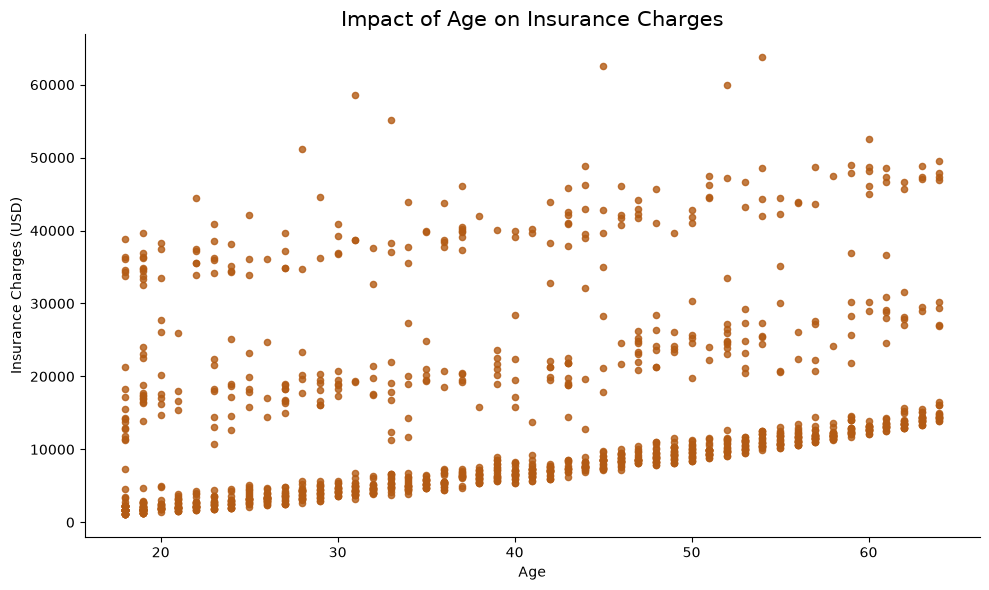

In [80]:
plt.figure(figsize=(10,6))
plt.scatter(
    df["age"],
    df["charges"],
    color=("#b35b14"), 
    alpha = 0.8,
    s = 20
)
plt.title("Impact of Age on Insurance Charges", fontsize= 15)
plt.xlabel("Age")
plt.ylabel("Insurance Charges (USD)")

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()


In [ ]:
plt.figure(figsize=(10,6))
plt.scatter(result5['age'], result5['charges'],
    color=("#b35b14"), 
    alpha = 0.8,
    s = 20)

plt.title("Impact of Age on Insurance Charges", fontsize= 15)
plt.xlabel("Age")
plt.ylabel("Insurance Charges (USD)")

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()


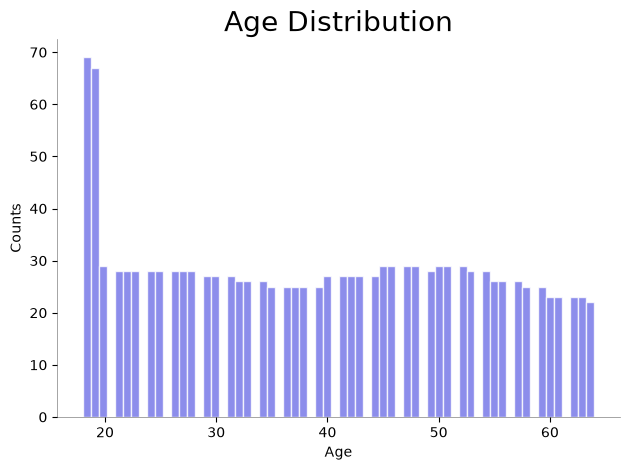

In [81]:
plt.hist(
    df["age"],
    bins=64,
    color=("#6f71e7"),
    alpha = 0.8,
    edgecolor="white"
    
)
plt.title("Age Distribution", fontsize= 20)
plt.xlabel("Age")
plt.ylabel("Counts")

ax = plt.gca()
for spine in ax.spines.values():
    spine.set_linewidth(0.5)
    spine.set_alpha(0.5)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()

plt.show()

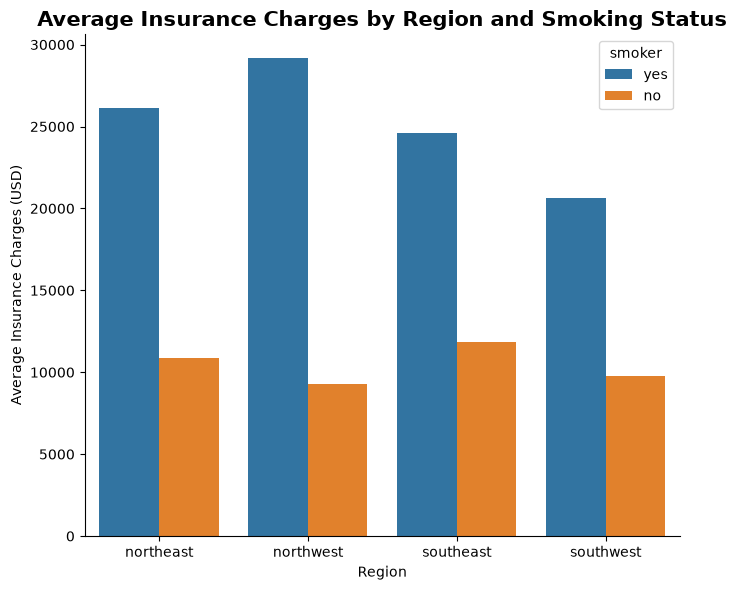

In [74]:
plt.figure(figsize=(7,6))
bmi_category_new= ['Underweight', 'Normal Weight', 'Overweight', 'Obese Class I', 'Obese Class II', 'Obese Class III']
average_charge = (df.groupby(["bmi_category", "smoker"])["charges"].mean().reset_index())

sns.barplot(data=result3,
            x="region",
            y="average_charges",
            hue="smoker",
            )

plt.ylabel("Average Insurance Charges (USD)")
plt.xlabel("Region")
plt.title("Average Insurance Charges by Region and Smoking Status", fontsize= 15, fontweight="bold")

ax=plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

In [ ]:
conn.close

<function Connection.close()>